Trần Hoàng Minh Thiên - 2550222

# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [1]:
STUDENT_NAME = "Trần Hoàng Minh Thiên"  # TODO: Họ và tên
STUDENT_ID = "2550222"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Trần Hoàng Minh Thiên (2550222)


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: C:\Users\user\Desktop\ML\homework\my work\mliot-pyml-2026-hw\week02\numpy-pandas-eda-hw\data\automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [3]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [4]:
# TODO N1
# shifted_logits = ...
shifted_logits = logits - np.max(logits, axis = 1, keepdims =True)
# exp_logits = ...
exp_logits = np.exp(shifted_logits)
# class_probabilities = ...
class_probabilities = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
# predicted_classes = ...
predicted_classes = np.argmax(class_probabilities, axis=1)
# confidence_scores = ...
confidence_scores = np.max(class_probabilities, axis=1)

In [5]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [6]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [7]:
# TODO N2
# train_feature_mean = ...
train_feature_mean = np.mean(X_train, axis=0)
# train_feature_std = ...
train_feature_std = np.std(X_train, axis=0)
# X_train_scaled = ...
X_train_scaled = (X_train - train_feature_mean) / train_feature_std
# X_val_scaled = ...
X_val_scaled = (X_val - train_feature_mean) / train_feature_std

In [8]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [9]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [10]:
# TODO N3
# correct_mask = ...
correct_mask = predicted_classes == true_labels
# high_confidence_mask = ...
high_confidence_mask = confidence_scores >= confidence_threshold
# review_mask = ...
review_mask = ~(correct_mask & high_confidence_mask)
# review_indices = ...
review_indices = np.where(review_mask)[0]

## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [11]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [12]:
# TODO N4
# normalized_batch = ...
normalized_batch = image_batch_uint8.astype(np.float32) / 255.0
# augmented_batch = ...
augmented_batch = np.copy(normalized_batch)[:, :, ::-1, :]
# augmented_batch[0, 0, 0, 0] = ...
augmented_batch[0, 0, 0, 0] = 1.0

# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

<!-- Viết câu trả lời tại đây. -->
1. Mỗi dòng đại diện cho các thông số kỹ thuật, thuộc tính thiết kế và mức giá của một mẫu xe ô tô cụ thể
2. Là dữ liệu khuyết thiếu trong bộ dữ liệu này được ký hiệu bằng dấu ?
3. symboling có ý nghĩa là thang điểm đánh giá mức độ rủi ro bảo hiểm của xe so với mức độ tương đối mà kích thước hay giá trị của xe mang

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [13]:
# TODO D1
# raw_df = ...
raw_df = pd.read_csv(DATA_PATH)
# raw_shape = ...
raw_shape = raw_df.shape
# raw_missing_marker_count = ...
raw_missing_marker_count = (raw_df == '?').sum().sum()

## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [14]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [15]:
# TODO D2
# df_clean = ...
df_clean = raw_df.replace('?', np.nan).copy()
# for column in NUMERIC_COLUMNS:
for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column])
#     ...
# missing_by_column = ...
missing_by_column = df_clean.isna().sum()

### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**

<!-- Viết 3--6 câu tại đây. -->
- Không nên fill tất cả numeric columns bằng cùng một giá trị vì mỗi cột có thang đo và phân phối hoàn toàn khác nhau
- Với cột price thì drop các dòng bị thiếu hợp lý hơn fill vì có thể làm nhiễu features và giá xe
- normalized_losses bị thiếu nhiều dữ liệu nên nếu fill thì sẽ tạo ra sai lệch lớn cho dữ liệu, còn nếu drop thì sẽ làm mất một lượng lớn mẫu quan trọng khác

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [16]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [17]:
# TODO D3
# analysis_df = ...
analysis_df = df_clean[AUTO_FEATURES].dropna().copy()
# X_auto = ...
X_auto = analysis_df.to_numpy(dtype=np.float64)
# auto_feature_mean = ...
auto_feature_mean = np.mean(X_auto, axis=0)
# auto_feature_std = ...
auto_feature_std = np.std(X_auto, axis=0)
# X_auto_scaled = ...
X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std

## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [18]:
# TODO D4
# price_index = ...
price_index = AUTO_FEATURES.index('price')
# price_z = ...
price_z = X_auto_scaled[:, price_index]
# price_outlier_mask = ...
price_outlier_mask = np.abs(price_z) > 2
# price_outliers = ...
price_outliers = analysis_df.iloc[price_outlier_mask]

## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [19]:
# TODO D5
# engine_price_corr = ...
engine_index = AUTO_FEATURES.index('engine_size')
price_index = AUTO_FEATURES.index('price')
# price_by_body_style = ...
engine_price_corr = np.corrcoef(X_auto[:, engine_index], X_auto[:, price_index])[0, 1]
price_by_body_style = df_clean.groupby('body_style')['price'].mean().sort_index()

# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

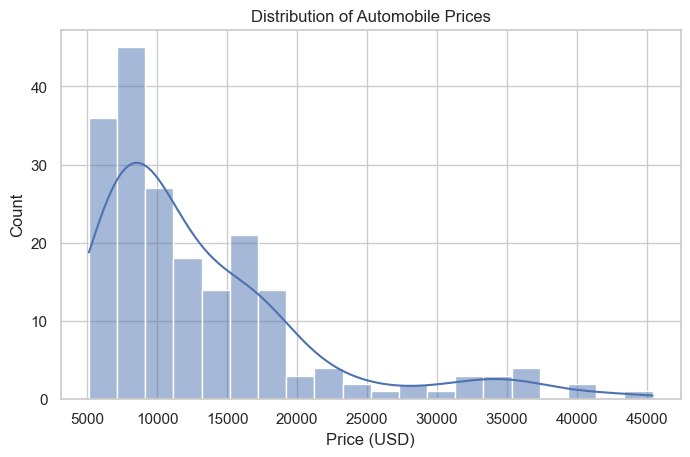

In [20]:
# TODO M2.1: histogram/KDE của price
sns.histplot(df_clean['price'].dropna(), kde=True, bins=20)
plt.title('Distribution of Automobile Prices')
plt.xlabel('Price (USD)')
plt.ylabel('Count')
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
Giá xe phân phối lệch phải, đa số các mẫu xe tập trung ở phân khúc dưới 15000 USD

## M2.2 Dataset có cân bằng theo body style không?

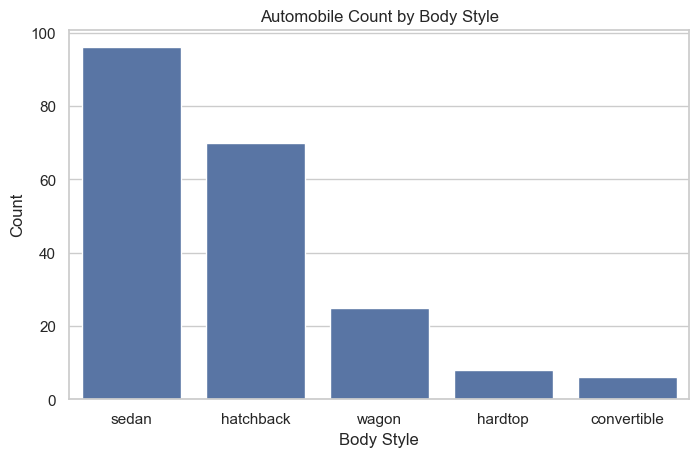

In [21]:
# TODO M2.2: countplot của body_style
sns.countplot(data=df_clean, x='body_style', order=df_clean['body_style'].value_counts().index)
plt.title('Automobile Count by Body Style')
plt.xlabel('Body Style')
plt.ylabel('Count')
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
Dữ liệu bị mất cân bằng, dòng sedan và hatchback chiếm phần lớn thị phần trong dataset trong khi các dòng như convertible hay hardtop lại rất ít

## M2.3 Price khác nhau theo body style ra sao?

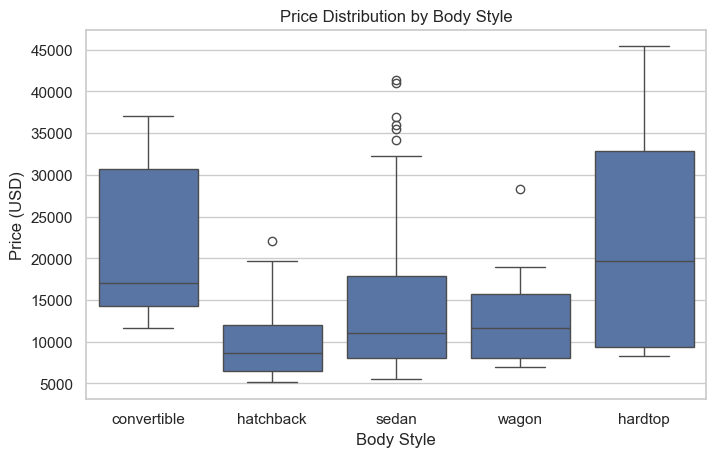

In [22]:
# TODO M2.3: boxplot price theo body_style
sns.boxplot(data=df_clean, x='body_style', y='price')
plt.title('Price Distribution by Body Style')
plt.xlabel('Body Style')
plt.ylabel('Price (USD)')
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
hardtop và convertible là hai dòng xe có mức gái trung vị coa nhất, hatchback nằm ở phân khúc giá rẻ và có khoảng giá hẹp

## M2.4 Engine size liên quan thế nào tới price?

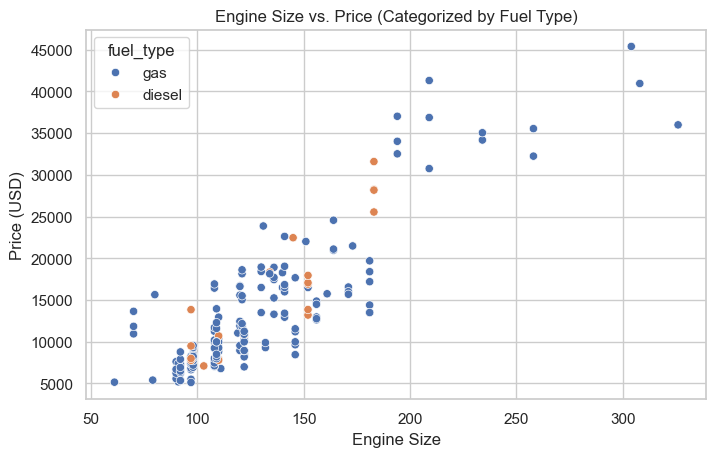

In [23]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type
sns.scatterplot(data=df_clean, x='engine_size', y='price', hue='fuel_type')
plt.title('Engine Size vs. Price (Categorized by Fuel Type)')
plt.xlabel('Engine Size')
plt.ylabel('Price (USD)')
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
Kích thước động cơ có tương quan mạnh với giá bán, xe chạy bằng nhiên liệu diesel thường nằm ở phân khúc giá và kích thước động cơ tầm trung

## M2.5 Các feature numeric tương quan ra sao?

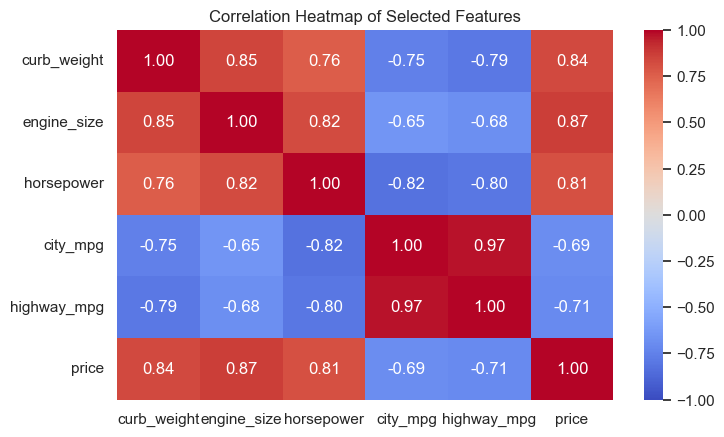

In [24]:
# TODO M2.5: correlation heatmap
corr = analysis_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Selected Features')
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
price có tương quan dương cao với engine_size, curb_weight và horsepower, có tương quan âm cao với city_mpg, highway_mpg

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

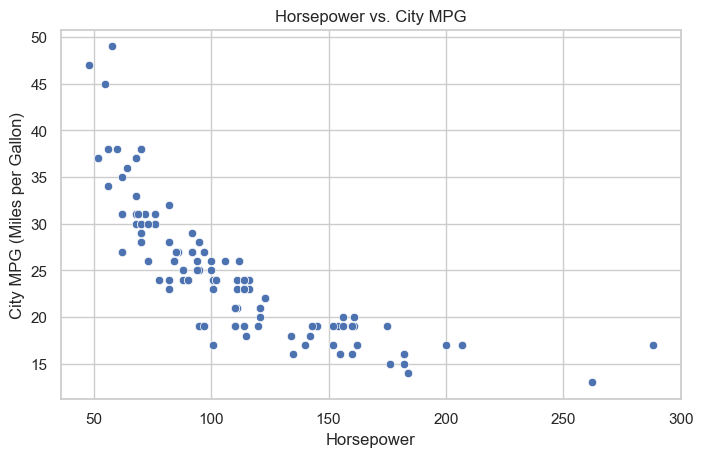

In [25]:
# TODO M2.6: biểu đồ tự chọn
sns.scatterplot(data=df_clean, x='horsepower', y='city_mpg')
plt.title('Horsepower vs. City MPG')
plt.xlabel('Horsepower')
plt.ylabel('City MPG (Miles per Gallon)')
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
Mã lực và hiệu suất nhiên liệu đi trong thành phố có mối quan hệ nghịch biến. 
Động cơ càng sinh nhiều mã lực thì càng tốn nhiên liệu

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

<!-- Viết khoảng 150--250 từ. -->
- Dựa vào quá trình EDA, em có 3 phát hiện chính:
1. Bộ dữ liệu lệch lớn về cả giá và kiểu dáng xe, chủ yếu tập trung vào phân khúc sedan và hatchback giá rẻ( dưới 15000 đô)
2. Giá trị của mọt chiếc xe bị chi phối mạnh bởi cấu hình cơ khí, engine_size , horsepower và  curb_weight có mối quan hệ tuyến tính thuận rõ rệt với price.
3. Có sự đánh đổi giữa sức mạnh động cơ và tính kinh tế, những xe có mã lực lớn thì sẽ tốn nhiều nhiên liệu hơn(MPG thấp).

- Hạn chế của dataset: Nó mất cân bằng hạng mục khá nhiều (vd như thiếu dữ liệu của convertible) dẫn đến các mô hình ML dự đoán trên nhóm này dễ bị sai lệch. Cột normalized_losses bị thiếu rất nhiều nên gây khó khăn trong việc đánh giá rủi ro tài chính của xe.

- Ví dụ về correlation không đồng nghĩa causation: mối quan hể giữa curb_weight và price. Biểu đồ cho thấy xe nặng hơn thì giá cao hơn nhưng trọng lượng không phải nguyên nhân trực tiếp làm tăng giá mà do xe đắt tiền thường được trang bị động cơ lớn hơn, khung gầm tốt hơn và vài yếu tố tựa tựa vậy nên xe mới nặng hơn.

- Câu hỏi nên phân tích tiếp: Sự khác biệt về hiệu suất nhiên liệu (MPG) giữa xe chạy bằng gas và diesel khi có cùng một kích thước động cơ (engine size) là như thế nào?

